Pricing supplement: https://www.sec.gov/Archives/edgar/data/1682472/000191870425014438/form424b2.htm

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime
from scipy.optimize import minimize, brentq, newton
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from scipy.stats import norm

# 1. Calibration Heston model

## 1.1. Fit $\kappa$ and $\theta$ from dataset 1.

In [122]:
quote_date = pd.to_datetime("2025/11/21")
df = pd.read_excel("Dataset1.xlsx").iloc[:-1,:]
maturities = (df["exp_date"] - quote_date).dt.days / 365
atm_vols = df["atm_vol"] / 100
v0 = atm_vols[0]**2

theta_init = 0.2084**2 # Initially only: ATM variance on Dec 2029.
print(f"v0 is {v0:.4f}, initial theta is {theta_init:.4f}.")

v0 is 0.0348, initial theta is 0.0434.


In [29]:
def calibrate_kappa_theta(params):
    kappa, theta = params
    expected_var = theta + (v0 - theta) * (1 - np.exp(-kappa * maturities)) / (kappa * maturities)
    squared_errors = np.sum((expected_var - atm_vols**2)**2)
    return squared_errors

In [123]:
# Optimize kappa and theta
kappa, theta = minimize(calibrate_kappa_theta,
                        x0=[1, theta_init],
                        method="trust-constr").x # bounds=[(0.1, 5), (1e-4, 1)],
print(f"kappa is {kappa:.4f}, theta is {theta:.4f}.")

kappa is 0.4857, theta is 0.0539.


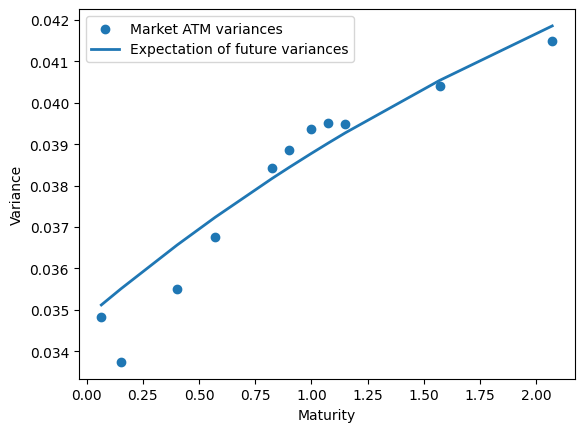

In [49]:
model_vars = theta + (v0 - theta) * (1 - np.exp(-kappa * maturities)) / (kappa * maturities)
plt.scatter(maturities, atm_vols**2, label="Market ATM variances")
plt.plot(maturities, model_vars, label="Expectation of future variances", lw=2)
plt.xlabel("Maturity")
plt.ylabel("Variance")
plt.legend()
plt.show()

## 1.2. Fit $\eta$ from dataset 1.

In [85]:
def black(F, K, T, r, sigma, flag=1):
  d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
  d2 = d1 - sigma * np.sqrt(T)
  return flag * np.exp(-r * T) * (F * norm.cdf(flag * d1) - K * norm.cdf(flag * d2))

def alpha_beta(u, j, kappa, eta, rho):
    # Note that 1j is imaginary part "i"
    alpha = -0.5 * (u**2 - 1j * (2 * j - 1) * u)
    beta  = kappa - j * rho * eta - 1j * rho * eta * u
    return alpha, beta

def d_forced(alpha, beta, eta):
    d = np.sqrt(beta**2 - 2 * eta**2 * alpha)
    d = np.where(np.real(d) < 0, -d, d)
    return d

def C_D(u, j, tau, kappa, theta, eta, rho):
    a = kappa * theta
    alpha, beta = alpha_beta(u, j, kappa, eta, rho)
    d = d_forced(alpha, beta, eta)

    g = (beta - d) / (beta + d)
    flip = np.abs(g) >= 1
    if np.any(flip):
        d = np.where(flip, -d, d)
        g = np.where(flip, 1/g, g)

    r2 = (beta - d) / eta**2
    exp_neg_dtau = np.exp(-d * tau)
    D = r2 * (1 - exp_neg_dtau) / (1 - g * exp_neg_dtau)
    C = a / eta**2 * ((beta - d) * tau - 2 * np.log((1 - g * exp_neg_dtau) / (1 - g)))
    return C, D

def heston_call(F, K, r, T, v0, kappa, theta, eta, rho,
                u_max=400.0, N=20000, eps=1e-4):
    x = np.log(F/K)

    # u = np.linspace(eps, u_max, N)
    u = eps + (u_max - eps) * np.linspace(0, 1, N)**2

    def phi(u, j):
        C, D = C_D(u, j, T, kappa, theta, eta, rho)
        return np.exp(C + D * v0 + 1j * u * x)

    def integrand(u, j):
        return np.real(phi(u, j) / (1j * u))

    # f0 = 0.5 + np.trapezoid(integrand(u, 0), u) / np.pi
    # f1 = 0.5 + np.trapezoid(integrand(u, 1), u) / np.pi
    f0 = 0.5 + simpson(integrand(u, 0), u) / np.pi
    f1 = 0.5 + simpson(integrand(u, 1), u) / np.pi

    return K * np.exp(-r * T) * (np.exp(x) * f1 - f0)

def implied_vol(F, K, T, r, price, flag=1):
    intrinsic = max(0, (F - K) if flag == 1 else (K - F)) * np.exp(-r * T)
    # If option price is lower than its intrisic value, add a linear penalty based on price gap
    if price <= intrinsic:
        diff = intrinsic - price
        return 1e-4 + diff / F

    f = lambda sigma: black(F, K, T, r, sigma, flag) - price
    try:
      iv = brentq(f, a=1e-6, b=20)
      # iv = newton(f, x0=0.2)
    except:
      iv = np.nan
    return iv

def vega(F, K, T, r, sigma):
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    vega = F * np.exp(-r * T) * norm.pdf(d1) * np.sqrt(T)
    return vega

In [134]:
mkt_F = df['imp_fwd']

ois_quote = pd.read_excel("OIS20251121.xlsx")
discount_curve = interp1d(ois_quote['Date'].astype(np.int64), ois_quote['Discount'], kind='linear')
discount = discount_curve(df['exp_date'].astype(np.int64))
rf = -np.log(discount) / maturities
rf=[rf.mean()]

def calibrate_eta(eta, lambdaF=10):
  heston_iv = np.zeros_like(mkt_F)
  for i, (fwd, maturity, r) in enumerate(zip(mkt_F, maturities, rf)):
    price = heston_call(fwd, fwd, r, maturity, v0, kappa, theta, eta, 0)
    heston_iv[i] = implied_vol(fwd, fwd, maturity, r, price, flag=1)
  mkt_vega = vega(mkt_F, mkt_F, maturities, r, atm_vols)
  squared_errors = np.nansum(((heston_iv - atm_vols) * mkt_vega)**2) + lambdaF * np.maximum(0, eta**2 - 2 * kappa * theta)**2 #
  return squared_errors

eta = minimize(calibrate_eta, x0=1, bounds=[(0.0001, None)], method="L-BFGS-B").x[0] # (0.05, 3)  trust-constr Nelder-Mead  COBYQA
print(f"eta is {eta:.4f}, Feller condition is satisfied: 2κθ-η²={2 * kappa * theta - eta**2:.4f} > 0.")

eta is 0.0002, Feller condition is satisfied: 2κθ-η²=0.0523 > 0.


## 1.3. Fit $\rho$ from dataset 2.

In [9]:
def clean_dataset(file, maturity, r, F, sub=False):
  '''
  sub: choose a subset of data.
  '''
  ds = pd.read_excel(file, header=1)

  # OTM call with volume higher than 10 and positive bid price
  call = ds.iloc[1:, :7]
  call = call[(call.Volm >= 10) & (call.Bid > 0) & (call.Strike > F) & (call.Strike <= 1.15 * spx)]
  if sub:
    call = call.head(12) #.iloc[::3]

  # OTM put with volume higher than 10 and positive bid price
  put = ds.iloc[1:, 7:]
  put.columns = call.columns
  put = put[(put.Volm >= 10) & (put.Bid > 0) & (put.Strike <= F) & (put.Strike >= 0.45 * spx)]
  if sub:
    put = put.tail(13) #.iloc[::3]

  ds = pd.concat([call, put]).sort_values(by='Strike').drop(columns=['Ticker', 'Last']).dropna()
  ds.reset_index(drop=True, inplace=True)
  ds.Strike = ds.Strike.astype(int)
  ds.IVM = ds.IVM / 100
  ds['Mid'] = (ds.Ask + ds.Bid) / 2

  ds['iv'] = 0.0
  for i, (K, price) in enumerate(zip(ds.Strike, ds.Mid)):
    flag = 1 if K > F else -1
    ds.loc[i, 'iv'] = implied_vol(F, K, maturity, r, price, flag)
    #if flag == -1:
    #  ds.loc[i, 'Mid'] += (F - K) * np.exp(-r * maturity) # Get call mid from PCP
    #  ds.loc[i, 'iv'] = implied_vol(F, K, maturity, r, ds.loc[i, 'Mid'], 1)

  ds['Spread'] = ds.Ask - ds.Bid
  ds['vega'] = vega(F, ds.Strike, maturity, r, ds.IVM) # ds.iv
  ds['vol_spread'] = ds['Spread'] / ds["vega"]

  return ds

In [112]:
def calculate_error(v0, kappa, theta, eta, rho, ds, r, F, maturity, epsilon=5e-4):
  heston_iv = np.zeros(ds.shape[0])
  heston_price = np.zeros(ds.shape[0])
  mkt_iv = ds.IVM
  strikes = ds.Strike

  for i, (K, mkt_iv) in enumerate(zip(strikes, mkt_iv)):
    flag = 1 if K > F else -1
    price = heston_call(F, K, r, maturity, v0, kappa, theta, eta, rho)
    if flag == -1:
      price += (K - F) * np.exp(-r * maturity) # Put price through Put-call parity on Black's model
      # flag = 1
    heston_iv[i] = implied_vol(F, K, maturity, r, price, flag)
    heston_price[i] = price

  # error = np.nansum(((heston_iv - mkt_iv) / ds["vega"])**2) # np.nanmean()
  # error = np.nansum(((heston_iv - mkt_iv) / np.maximum(epsilon, ds["vol_spread"]))**2)
  # error = np.nanmean(((heston_price - ds.Mid) / np.maximum(epsilon, ds.Spread))**2)
  error = np.nanmean(((heston_price - ds.Mid) / np.maximum(epsilon, ds.vega))**2) #ds.Spread*

  return error

In [98]:
spx = 6602.99

maturity1 = (pd.to_datetime("2025/12/19") - quote_date).days / 365
discount1 = discount_curve(pd.to_datetime("2025/12/19").value)
rf1 = -np.log(discount1) / maturity1
Fwd1 = spx / discount1
ds1 =  clean_dataset("19_Dec_2025_All.xlsx", maturity1, rf1, Fwd1)

maturity2 = (pd.to_datetime("2026/03/20") - quote_date).days / 365
discount2 = discount_curve(pd.to_datetime("2026/03/20").value)
rf2 = -np.log(discount2) / maturity2
Fwd2 = spx / discount2
ds2 = clean_dataset("20_Mar_2026_All.xlsx", maturity2, rf2, Fwd2)

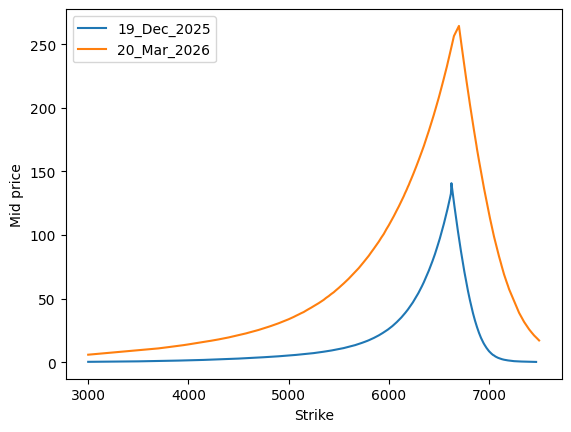

In [36]:
plt.plot(ds1.Strike, ds1.Mid)
plt.plot(ds2.Strike, ds2.Mid)
plt.legend(["19_Dec_2025", "20_Mar_2026"])
plt.xlabel("Strike")
plt.ylabel("Mid price")
plt.show()

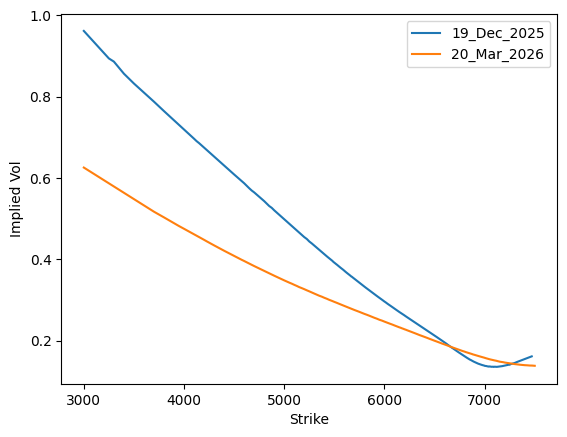

In [95]:
plt.plot(ds1.Strike, ds1.IVM)
plt.plot(ds2.Strike, ds2.IVM)
plt.legend(["19_Dec_2025", "20_Mar_2026"])
plt.xlabel("Strike")
plt.ylabel("Implied Vol")
plt.show()

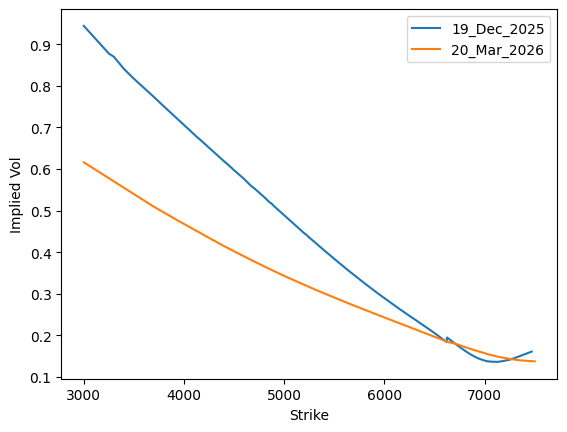

In [96]:
plt.plot(ds1.Strike, ds1.iv)
plt.plot(ds2.Strike, ds2.iv)
plt.legend(["19_Dec_2025", "20_Mar_2026"])
plt.xlabel("Strike")
plt.ylabel("Implied Vol")
plt.show()

In [135]:
calibrate_rho = lambda rho: calculate_error(v0, kappa, theta, eta, rho, ds1, rf1, Fwd1, maturity1) + \
                            calculate_error(v0, kappa, theta, eta, rho, ds2, rf2, Fwd2, maturity2)

rho = minimize(calibrate_rho, x0=-0.5, bounds=[(-1, 1)], method="trust-constr",
               ).x[0] # (-0.95, 0.95) L-BFGS-Boptions={'eps': 1e-3,'ftol': 1e-5}
print(f"rho is {rho:.4f}.")

rho is -0.4301.


## 1.4. Fit $\eta$ and $\rho$ together from dataset 3.

In [106]:
def calibrate_eta_rho(params, lambdaF=10):
  eta, rho = params
  error = calculate_error(v0, kappa, theta, eta, rho, du1, r[0], F[0], mat[0], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du2, r[1], F[1], mat[1], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du3, r[2], F[2], mat[2], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du4, r[3], F[3], mat[3], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du5, r[4], F[4], mat[4], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du6, r[5], F[5], mat[5], True) + \
          lambdaF * np.maximum(0, eta**2 - 2 * kappa * theta)**2
  return error

In [107]:
mat_list = ['20260320', '20260618', '20260918', '20270617', '20271217', '20291221']
mat = (pd.to_datetime(mat_list) - quote_date).days / 365
d = discount_curve(pd.to_datetime(mat_list).astype(np.int64))
r = (-np.log(d) / mat).to_numpy()
F = spx / d
du1 = clean_dataset(f"{mat_list[0]}.xlsx", mat[0], r[0], F[0])
du2 = clean_dataset(f"{mat_list[1]}.xlsx", mat[1], r[1], F[1])
du3 = clean_dataset(f"{mat_list[2]}.xlsx", mat[2], r[2], F[2])
du4 = clean_dataset(f"{mat_list[3]}.xlsx", mat[3], r[3], F[3])
du5 = clean_dataset(f"{mat_list[4]}.xlsx", mat[4], r[4], F[4])
du6 = clean_dataset(f"{mat_list[5]}.xlsx", mat[5], r[5], F[5])

/tmp/ipython-input-2523296325.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ds = pd.concat([call, put]).sort_values(by='Strike').drop(columns=['Ticker', 'Last']).dropna()
/tmp/ipython-input-2523296325.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ds = pd.concat([call, put]).sort_values(by='Strike').drop(columns=['Ticker', 'Last']).dropna()


In [18]:
eta, rho = 0.2553, -0.9683

In [136]:
eta_init, rho_init = eta, rho
eta, rho = minimize(calibrate_eta_rho, x0=[eta_init, rho_init], bounds=[(0.0001, None), (-1, 1)],
                    method="trust-constr").x
# Nelder-Mead(0.05, 3), (-0.95, 0.95) tol=1e-6, options={'eps': 1e-3,'ftol': 1e-5} L-BFGS-B
print(f"eta is {eta:.4f}, rho is {rho:.4f}.")

eta is 0.2335, rho is -0.9999.


## 1.5. Fit all parameters together from dataset 3.

In [148]:
def calibrate_all_box(params, lambdaF=10, lambdaB=10):
  v0, kappa, theta, eta, rho = params
  error = calculate_error(v0, kappa, theta, eta, rho, du1, r[0], F[0], mat[0], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du2, r[1], F[1], mat[1], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du3, r[2], F[2], mat[2], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du4, r[3], F[3], mat[3], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du5, r[4], F[4], mat[4], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du6, r[5], F[5], mat[5], True) + \
          lambdaF * np.maximum(0, eta**2 - 2 * kappa * theta)**2 + \
          lambdaB * (np.maximum(0, 0.0001 - v0)**2 + np.maximum(0, v0 - 1)**2) + \
          lambdaB * (np.maximum(0, 0.1 - kappa)**2 + np.maximum(0, kappa- 5)**2) + \
          lambdaB * (np.maximum(0, 0.0001 - theta)**2 + np.maximum(0, theta - 1)**2) + \
          lambdaB * (np.maximum(0, 0.05 - eta)**2 + np.maximum(0, eta - 3)**2) + \
          lambdaB * (np.maximum(0, -0.95 - rho)**2 + np.maximum(0, rho - 0.95)**2)

  return error

def calibrate_all(params, lambdaF=10):
  v0, kappa, theta, eta, rho = params
  error = calculate_error(v0, kappa, theta, eta, rho, du1, r[0], F[0], mat[0], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du2, r[1], F[1], mat[1], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du3, r[2], F[2], mat[2], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du4, r[3], F[3], mat[3], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du5, r[4], F[4], mat[4], True) + \
          calculate_error(v0, kappa, theta, eta, rho, du6, r[5], F[5], mat[5], True) + \
          lambdaF * np.maximum(0, eta**2 - 2 * kappa * theta)**2

  return error

In [137]:
v0_init, kappa_init, theta_init, eta_init, rho_init = v0, kappa, theta, eta, rho
v0, kappa, theta, eta, rho = minimize(calibrate_all, x0=[v0_init, kappa_init, theta_init, eta_init, rho_init],
                                      bounds=[(0.0001, 1), (0.1, 5), (0.0001, 1), (0.05, 3), (-0.95, 0.95)], method="L-BFGS-B").x # Nelder-Mead trust-constr

In [138]:
print(f"v0 is {v0:.4f}, kappa is {kappa:.4f}, theta is {theta:.4f}, eta is {eta:.4f}, rho is {rho:.4f}")
      #f", Feller condition is satisfied: 2κθ-η²={2 * kappa * theta - eta**2:.4f} > 0.")

v0 is 0.0363, kappa is 1.8943, theta is 0.0605, eta is 0.4796, rho is -0.9500, Feller condition is satisfied: 2κθ-η²=-0.0007 > 0.


# 2. Pricing callable option

## 2.1. Dates and Features

In [2]:
v0 = 0.0363
kappa = 1.8943
theta = 0.0605
eta = 0.4796
rho = -0.95

In [56]:
pricing_date = pd.to_datetime("2025-08-29")
issue_date = pd.to_datetime("2025-09-04")
valuation_date = pd.to_datetime("2029-08-29")
maturity_date = pd.to_datetime("2029-09-04")

observation_dates = pd.to_datetime([
    "2025-12-01",
    "2026-03-02", "2026-05-29", "2026-08-31", "2026-11-30",
    "2027-03-01", "2027-06-01", "2027-08-30", "2027-11-29",
    "2028-02-29", "2028-05-30", "2028-08-29", "2028-11-29",
    "2029-02-28", "2029-05-29", "2029-08-29"
])

autocall_dates = observation_dates[3:-1]

coupon_dates = pd.to_datetime([
    "2025-12-04",
    "2026-03-05", "2026-06-03", "2026-09-03", "2026-12-03",
    "2027-03-04", "2027-06-04", "2027-09-02", "2027-12-02",
    "2028-03-03", "2028-06-02", "2028-09-01", "2028-12-04",
    "2029-03-05", "2029-06-01", "2029-09-04"
])

# autocall_pay_dates = coupon_dates[3:-1]

obs_to_coupon = (coupon_dates - observation_dates).days.to_numpy() / 365

S0 = 6460.26
autocall_value = S0
threshold_value = 0.7 * S0
coupon_barrier = 0.7 * S0
coupon_rate = 0.073 / 4  # Quarterly rate
principal = 1000
estimated_value = 992.70  # Estimated value on the pricing date from description

## 2.2. Parameters of Stocks

In [57]:
# Interest rate and discount rate between pricing date and valuation date for stock price movements
discount1 = 0.878949
r1 = -np.log(discount1) / ((valuation_date - pricing_date).days / 365)

# Interest rate and discount rate between issue date and maturity date for discounting
discount2 = 0.878081
r2 = -np.log(discount2) / ((maturity_date - issue_date).days / 365)

# dates of implied volatility and dates we need
quote_dates = pd.to_datetime([
    "2025-09-25", "2025-12-29",
    "2026-03-29", "2026-06-29", "2026-09-29", "2026-12-29",
    "2027-03-29", "2027-06-29", "2027-09-29", "2027-12-29",
    "2028-03-29", "2028-06-29", "2028-09-29", "2028-12-29",
    "2029-03-29", "2029-06-29", "2029-09-29"
])

# volatility vector corresponding to coupon barrier
quoted_sigma_barrier = np.array([
    0.49801, 0.35111,
    0.31465, 0.29364, 0.27978, 0.27051,
    0.26464, 0.26012, 0.25611, 0.25318,
    0.25092, 0.24901, 0.24748, 0.24637,
    0.24566, 0.24521, 0.24498
])
sigma_vec_barrier = interp1d(quote_dates.astype(np.int64), quoted_sigma_barrier, kind='linear')(observation_dates.astype(np.int64))
sigma_barrier = sigma_vec_barrier[-1]
sigma_avg_barrier = sigma_vec_barrier.mean()

# volatility vector corresponding to at-the-money price
quoted_sigma_atm = np.array([
    0.11965, 0.14532,
    0.15739, 0.16435, 0.16992, 0.17335,
    0.17595, 0.17809, 0.17999, 0.18188,
    0.18375, 0.18588, 0.18800, 0.19022,
    0.19258, 0.19506, 0.19747
])
sigma_vec_atm = interp1d(quote_dates.astype(np.int64), quoted_sigma_atm, kind='linear')(observation_dates.astype(np.int64))
sigma_atm = sigma_vec_atm[-1]
sigma_avg_atm = sigma_vec_atm.mean()

# dividend yield
delta = 0.01304

## 2.3. Pricing models
### 2.3.1. Binomial Pricer

In [58]:
def AutoCallable_Contingent_binomial_pricer(r1, r2, sigma, delta, scale):
  '''
  r1 is the interest rate indicating stock price movements
  r2 is the interest rate indicating discounting
  sigma is the volatility of stock
  delta is the continuous dividend yield of stock
  '''
  # time step and dates
  dt = 1 / 365 / scale
  N = int((valuation_date - pricing_date).days / 365 / dt)

  observation_steps = ((observation_dates - pricing_date).days / 365 / dt).astype(int).to_numpy()
  autocall_steps = observation_steps[3:-1]
  coupon_steps = ((coupon_dates - pricing_date).days / 365 / dt).astype(int).to_numpy()
  observation_to_coupon = dict(zip(observation_steps, coupon_steps - observation_steps))

  # calculate tree parameters
  u = np.exp(sigma * np.sqrt(dt))
  d = np.exp(-sigma * np.sqrt(dt))
  q = (np.exp((r1 - delta) * dt) - d) / (u - d)
  disc = np.exp(-r2 * dt)

  # build stock price tree
  S = np.zeros((N + 1, N + 1))
  for i in range(0, N + 1):
    j = np.arange(i + 1)
    S[i, j] = S0 * u**j * d**(i-j)

  # value the product
  V = np.zeros((N + 1, N + 1))

  # valuation date
  for i in range(N, -1, -1):
    j = np.arange(i + 1)
    contingent_coupon = np.where(S[i, j]>=coupon_barrier, principal * coupon_rate, 0)
    if i == N:
      V[i, j] = (np.where(S[i, j]>=threshold_value, principal, principal * S[i, j] / S0) + contingent_coupon) * disc**observation_to_coupon[i]
    elif i in autocall_steps:
      V[i, j] = np.where(S[i, j]>=autocall_value, principal, disc * (q * V[i + 1, j + 1] + (1 - q) * V[i + 1, j])) \
                +  contingent_coupon * disc**observation_to_coupon[i]
    elif i in observation_dates:
      V[i, j] = disc * (q * V[i + 1, j + 1] + (1 - q) * V[i + 1, j]) + contingent_coupon * disc**observation_to_coupon[i]
    else:
      V[i, j] = disc * (q * V[i + 1, j + 1] + (1 - q) * V[i + 1, j])

  return V[0, 0]

In [59]:
print(f"ATM volatility at maturity = {sigma_atm:.4f}, "
      f"price = {AutoCallable_Contingent_binomial_pricer(r1, r2, sigma_atm, delta, 1):.4f}.")
print(f"Mean of ATM volatility on observation dates = {sigma_avg_atm:.4f}, "
      f"price = {AutoCallable_Contingent_binomial_pricer(r1, r2, sigma_avg_atm, delta, 1):.4f}.")
print(f"coupon barrier volatility at maturity = {sigma_barrier:.4f}, "
      f"price = {AutoCallable_Contingent_binomial_pricer(r1, r2, sigma_barrier, delta, 1):.4f}.")
print(f"Mean of coupon barrier volatility on observation dates = {sigma_avg_barrier:.4f}, "
      f"price = {AutoCallable_Contingent_binomial_pricer(r1, r2, sigma_avg_barrier, delta, 1):.4f}.")

ATM volatility at maturity = 0.1967, price = 950.1704.
Mean of ATM volatility on observation dates = 0.1772, price = 964.0314.
coupon barrier volatility at maturity = 0.2451, price = 917.7751.
Mean of coupon barrier volatility on observation dates = 0.2719, price = 902.6655.


### 2.3. Monte Carlo Pricer

In [60]:
def simulate_stock_price(N, M, r, delta, v0, kappa, theta, eta, rho):
  np.random.seed(42)
  Z = np.random.normal(size=(N, M, 2))
  V = np.zeros((N, M+1))
  V[:, 0] = v0
  S = np.zeros((N, M+1))
  S[:, 0] = S0
  prev_date = pricing_date
  for i in range(M):
    dt = (observation_dates[i] - prev_date).days / 365
    dWV = (rho * Z[:, i, 0] + np.sqrt(1 - rho**2) * Z[:, i, 1]) * np.sqrt(dt)
    V[:, i+1] = np.maximum(V[:, i] + kappa * (theta - V[:, i]) * dt + eta * np.sqrt(V[:, i]) * dWV, 0)
    dWS = Z[:, i, 0] * np.sqrt(dt)
    S[:, i+1] = S[:, i] * np.exp((r - delta - 0.5 * V[:, i]) * dt + np.sqrt(V[:, i]) * dWS)
    prev_date = observation_dates[i]
  return S

def payment_at_maturity(ST):
  contingent_coupon = np.where(ST >= coupon_barrier, principal * coupon_rate, 0)
  payment = np.where(ST >= threshold_value, principal, principal * (ST / S0))
  return payment + contingent_coupon

def chebyshev_basis(x, k=3):
    B = [np.ones(len(x)), x]
    for n in range(2, k+1):
        Bn = 2 * x * B[n - 1] - B[n - 2]
        B.append(Bn)

    return np.column_stack(B)

def AutoCallable_Contingent_MC_pricer(N, r1, r2, delta, v0, kappa, theta, eta, rho):
  '''
  r1 is the interest rate indicating stock price movements
  r2 is the interest rate indicating discounting
  sigma is the volatility of stock
  delta is the continuous dividend yield of stock
  N is the number of simulation paths
  '''
  M = len(observation_dates)
  S = simulate_stock_price(N, M, r1, delta, v0, kappa, theta, eta, rho)

  obs_to_coupon = (coupon_dates - observation_dates).days / 365
  discounted_future_value = payment_at_maturity(S[:, -1]) * np.exp(-r2 * obs_to_coupon[-1]) # discount value from coupon date to observation date
  for i in range(M-2, -1, -1):
    # discount future value and contingent coupon to current time
    contingent_coupon = np.where((S[:, i+1]>=coupon_barrier), principal * coupon_rate, 0)
    discounted_future_value = discounted_future_value * np.exp(-r2 * (observation_dates[i+1] - observation_dates[i]).days / 365)
    if observation_dates[i] in autocall_dates:
      discounted_future_value = np.where(S[:, i+1] >= autocall_value, principal, discounted_future_value)
    discounted_future_value += contingent_coupon * np.exp(-r2 * obs_to_coupon[i])

  # i = 0, get the value on the first observation date
  discounted_future_value *= np.exp(-r2 * (observation_dates[0] - pricing_date).days / 365) # discount to pricing date

  return discounted_future_value.mean()#, discounted_future_value.std()/np.sqrt(N)

In [139]:
N = 500000
print(f"Monte Carlo price = {AutoCallable_Contingent_MC_pricer(N, r1, r2, delta, v0, kappa, theta, eta, rho):.4f}.")

Monte Carlo price = 977.1149.


## 2.4. Sensitive Analysis

In [155]:
print(f"Monte Carlo price = {AutoCallable_Contingent_MC_pricer(N, r1, r2, delta, 0.0441, 1.4240, 0.0708, 0.9808, -0.7308):.4f}.")

Monte Carlo price = 955.1053.
